# GitHub OSS Repos for Founder Fade Study

This demo loads a curated dataset of public GitHub OSS repositories and computes proxy survival labels (ACTIVE/INACTIVE) based on contributor count and activity metrics. The dataset serves as a candidate pool for the Founder Fade hypothesis, which investigates whether the shape of founder involvement decline predicts project survival.

**What this notebook does:**
- Loads repository metadata from a JSON dataset
- Computes activity ratios and proxy survival labels
- Analyzes the distribution of ACTIVE vs INACTIVE projects
- Visualizes key metrics across programming languages

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0', 'seaborn==0.13.2')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import os
import sys
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# GitHub data URL for loading
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-ad55a2-founder-fade-curve-predicts-oss-survival/main/round-1/dataset-1/demo/mini_demo_data.json"

In [3]:
def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {data['metadata']['total_examples']} examples")
print(f"Source: {data['metadata']['source_datasets']}")

Loaded 50 examples
Source: ['h1alexbel/github-repos (14,428 repos, MIT license, collected via ghminer tool)']


## Configuration

Tunable parameters for the analysis. These control the thresholds for the proxy survival label and the scope of processing.

In [5]:
# Analysis configuration
n_samples = min(50, data['metadata']['total_examples'])  # Number of examples to process
contributors_threshold = 5  # Minimum contributors for ACTIVE label
stars_threshold = 1000  # Minimum stars for secondary ACTIVE criteria
activity_ratio_threshold = 0.5  # Minimum commits/day for secondary ACTIVE criteria
inactive_contributors_max = 2  # Maximum contributors for INACTIVE label
inactive_activity_max = 0.1  # Maximum activity ratio for INACTIVE label

## Data Processing

Parse the dataset and compute proxy survival labels based on contributor count and activity metrics. The logic mirrors the original `data.py` script.

In [6]:
# Extract examples and process
examples = data['datasets'][0]['examples'][:n_samples]

# Parse all examples into a structured format
processed = []
for ex in examples:
    features = json.loads(ex['input'])
    processed.append({
        'repo': features['repo'],
        'language': features.get('language', 'Unknown'),
        'contributors': int(features.get('contributors', 0)),
        'commits': int(features.get('commits', 0)),
        'stars': int(features.get('stars', 0)),
        'forks': int(features.get('forks', 0)),
        'issues': int(features.get('issues', 0)),
        'created_at': features.get('created_at', ''),
        'last_commit_date': features.get('last_commit_date', ''),
        'label': ex['output'],  # Ground truth label from dataset
    })

df = pd.DataFrame(processed)
print(f"Processed {len(df)} repositories")

Processed 50 repositories


## Compute Activity Metrics

Calculate activity ratios and recompute labels using the configured thresholds.

In [7]:
def compute_activity_label(row):
    """Compute proxy survival label based on thresholds."""
    created = pd.to_datetime(row['created_at'], errors='coerce')
    last_commit = pd.to_datetime(row['last_commit_date'], errors='coerce')
    
    contributors = row['contributors']
    commits = row['commits']
    stars = row['stars']
    
    if pd.notna(last_commit) and pd.notna(created):
        age_days = (last_commit - created).days
        if age_days > 0:
            activity_ratio = commits / max(age_days, 1)
        else:
            activity_ratio = 0
    else:
        activity_ratio = 0
    
    # Apply thresholds
    if contributors >= contributors_threshold:
        return 'ACTIVE', activity_ratio
    elif contributors <= inactive_contributors_max and activity_ratio < inactive_activity_max:
        return 'INACTIVE', activity_ratio
    elif stars >= stars_threshold and activity_ratio >= activity_ratio_threshold:
        return 'ACTIVE', activity_ratio
    else:
        return 'ACTIVE', activity_ratio  # default to active

# Compute labels and activity ratios
results = [compute_activity_label(row) for _, row in df.iterrows()]
df['computed_label'] = [r[0] for r in results]
df['activity_ratio'] = [r[1] for r in results]

print(f"\nLabel distribution:")
print(df['computed_label'].value_counts())


Label distribution:
computed_label
ACTIVE      30
INACTIVE    20
Name: count, dtype: int64


## Results Visualization

Plot the distribution of labels, activity ratios, and repository metrics.

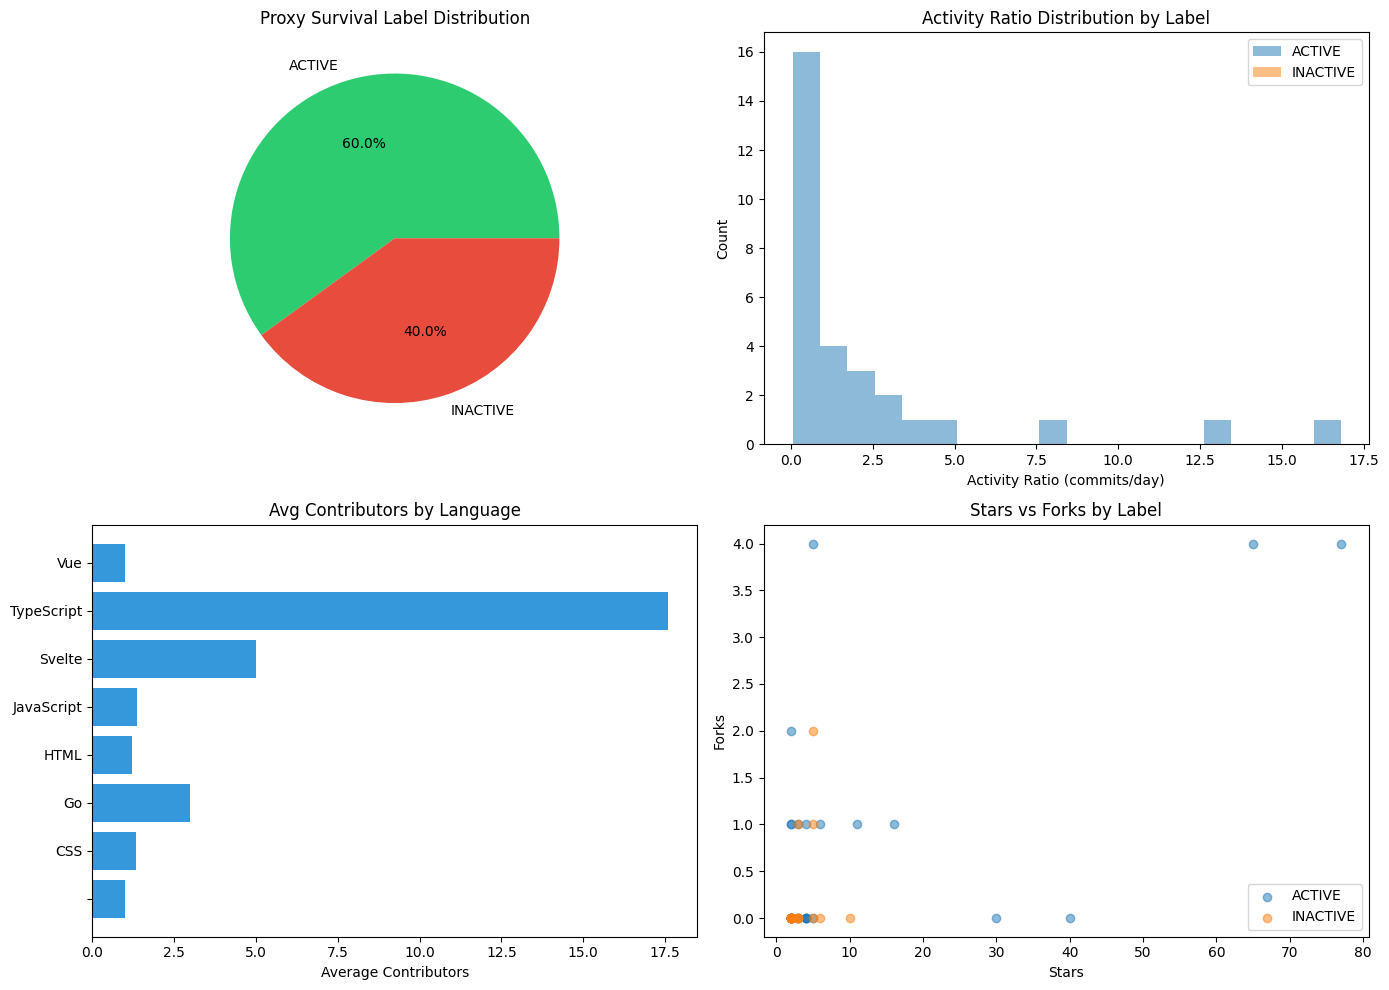

In [8]:
# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Label distribution
ax1 = axes[0, 0]
label_counts = df['computed_label'].value_counts()
colors = ['#2ecc71', '#e74c3c']
ax1.pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%', colors=colors)
ax1.set_title('Proxy Survival Label Distribution')

# 2. Activity ratio by label
ax2 = axes[0, 1]
for label in ['ACTIVE', 'INACTIVE']:
    subset = df[df['computed_label'] == label]['activity_ratio']
    ax2.hist(subset, alpha=0.5, bins=20, label=label)
ax2.set_xlabel('Activity Ratio (commits/day)')
ax2.set_ylabel('Count')
ax2.set_title('Activity Ratio Distribution by Label')
ax2.legend()

# 3. Contributors by language
ax3 = axes[1, 0]
top_langs = df['language'].value_counts().head(8).index
lang_contributors = df[df['language'].isin(top_langs)].groupby('language')['contributors'].mean()
ax3.barh(lang_contributors.index, lang_contributors.values, color='#3498db')
ax3.set_xlabel('Average Contributors')
ax3.set_title('Avg Contributors by Language')

# 4. Stars vs Forks scatter
ax4 = axes[1, 1]
for label in ['ACTIVE', 'INACTIVE']:
    subset = df[df['computed_label'] == label]
    ax4.scatter(subset['stars'], subset['forks'], alpha=0.5, label=label)
ax4.set_xlabel('Stars')
ax4.set_ylabel('Forks')
ax4.set_title('Stars vs Forks by Label')
ax4.legend()

plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Summary statistics table
summary = df.groupby('computed_label').agg({
    'repo': 'count',
    'contributors': ['mean', 'median'],
    'commits': ['mean', 'median'],
    'stars': ['mean', 'median'],
    'activity_ratio': 'mean'
}).round(2)
print("\nSummary Statistics by Label:")
print(summary)


Summary Statistics by Label:
                repo contributors        commits         stars         \
               count         mean median    mean median   mean median   
computed_label                                                          
ACTIVE            30         4.33    1.0   80.73   26.5  10.33    3.0   
INACTIVE          20         1.05    1.0    7.30    4.5   3.30    2.5   

               activity_ratio  
                         mean  
computed_label                 
ACTIVE                   2.29  
INACTIVE                 0.02  
